In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from xgboost import XGBRegressor
import joblib
import os

In [4]:
df = pd.read_csv("../data/Processed/Timeseries_cleaned.csv")
df.head()

,date,store,item,sales,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,...,day_of_week,dow_sin,dow_cos,month_sin,month_cos,trend,diff_1,roc_7,store_avg_sales,item_avg_sales
0,2013-01-29,1,1,6,11.0,7.0,5.0,13.0,10.428571,10.642857,...,1,0.781831,0.623490,0.500000,0.866025,28,-5.0,-0.142857,47.268379,21.981599
1,2013-01-30,1,1,9,6.0,9.0,7.0,11.0,10.285714,10.714286,...,2,0.974928,-0.222521,0.500000,0.866025,29,3.0,0.000000,47.268379,21.981599
2,2013-01-31,1,1,13,9.0,8.0,16.0,14.0,10.285714,10.857143,...,3,0.433884,-0.900969,0.500000,0.866025,30,4.0,0.625000,47.268379,21.981599
3,2013-02-01,1,1,11,13.0,14.0,7.0,13.0,11.000000,10.642857,...,4,-0.433884,-0.900969,0.866025,0.500000,31,-2.0,-0.214286,47.268379,21.981599
4,2013-02-02,1,1,21,11.0,12.0,18.0,10.0,10.571429,10.928571,...,5,-0.974928,-0.222521,0.866025,0.500000,32,10.0,0.750000,47.268379,21.981599


In [5]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["store","item","date"])

In [6]:
target = "sales"
features = [col for col in df.columns if col not in ["sales","date"]]

In [7]:
split_date = "2016-01-01"

train = df[df["date"] < split_date]
test  = df[df["date"] >= split_date] 

X_train = train[features]
y_train = train[target]

X_test =  test[features]
y_test = test[target]

In [8]:
print(train["date"].min(),train["date"].max())
print(test["date"].min(),test["date"].max())

2013-01-29 00:00:00 2015-12-31 00:00:00
2016-01-01 00:00:00 2017-12-31 00:00:00


In [9]:
print("INF in X_train:", np.isinf(X_train).sum().sum())
print("INF in y_train:", np.isinf(y_train).sum())

print("NaN in X_train:", X_train.isnull().sum().sum())
print("NaN in y_train:", y_train.isnull().sum())

INF in X_train: 1
INF in y_train: 0
NaN in X_train: 0
NaN in y_train: 0


In [10]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

In [11]:
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]

In [12]:
df["roc_7"] = (
    df.groupby(["store","item"])["sales"]
    .pct_change(7)
    .replace([np.inf, -np.inf], 0)
)

In [13]:
# remove inf
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

# fill missing
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    n_jobs=-1
)

# train
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [14]:
y_pred = model.predict(X_test)

In [15]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)

MAE : 0.6862639784812927
MSE : 1.005192518234253
RMSE : 1.002592921257019


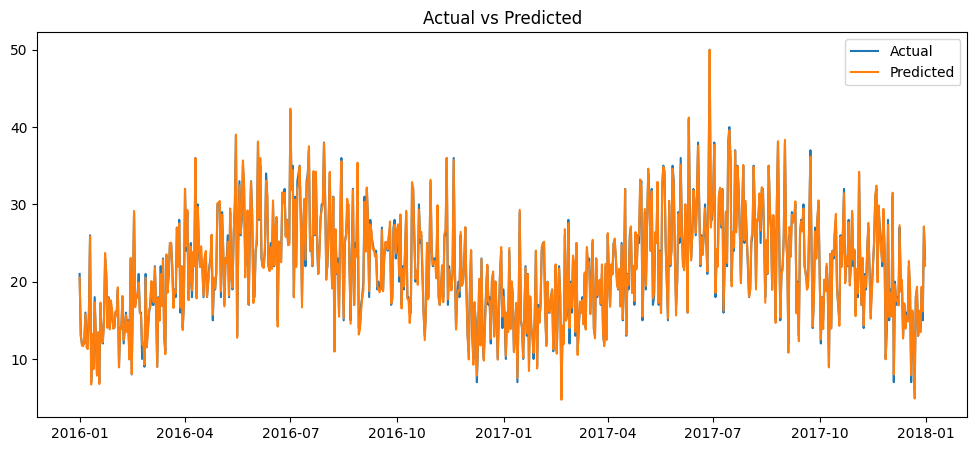

In [16]:
test = test.copy()
test["pred"] = y_pred

sample = test[(test["store"]==1) & (test["item"]==1)]

plt.figure(figsize=(12,5))

plt.plot(sample["date"], sample["sales"], label="Actual")
plt.plot(sample["date"], sample["pred"], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [17]:
BASE_DIR = os.path.abspath("..")
model_path = os.path.join(BASE_DIR,"models","timeseries_model.pkl")

final_model = model
final_model.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [18]:
joblib.dump(final_model,model_path)

['c:\\Users\\LENOVO\\Downloads\\Zidio project\\RetailPulse\\models\\timeseries_model.pkl']